In [7]:
%reload_ext autoreload
%autoreload 2
import xmitgcm as xm
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
%matplotlib widget
import matplotlib.colors as mcolors
import xhistogram.xarray as xhist
import jmkfigure
import os
from pathlib import Path

def preprocess_run(ds):
    ds = ds.isel(YC=0, YG=0)
    ds['XG'] = (ds.XG - ds.XC[-1])/1e3
    ds['XC'] = (ds.XC - ds.XC[-1])/1e3
    return ds
# define some things we will use throughout:
lognorm = mcolors.LogNorm(vmin=1e-10, vmax=1e-6)
thetalevels = np.arange(20, 28, 0.2)
thetalevelsmaj = np.arange(20, 28, 1)
thetalevelspecial = np.array([25.6])
# remove maj from thetalevels:
thetalevels = thetalevels[~np.isin(thetalevels, thetalevelsmaj)]

cmapKL = plt.get_cmap('hot_r')
cmapU = plt.get_cmap('RdBu_r')

def contour_theta(ds, timeidx=0, ax=None, thetalevelspecial=None):
    if timeidx is None:
        Theta = ds.THETA
    else:
        Theta = ds.THETA.isel(time=timeidx)
    cs = ax.contour(ds.XC, ds.Z, Theta, colors='k', levels=thetalevels, linewidths=0.5)
    ax.contour(ds.XC, ds.Z, Theta, colors='k', levels=thetalevelsmaj, linewidths=1)
    if thetalevelspecial is not None:
        ax.contour(ds.XC, ds.Z, Theta, colors='m', levels=thetalevelspecial, linewidths=1.5)
    return cs

mooringX = np.array([-36, -31, -24])
mooringX = np.array([-55, -45, -35]) # Slope2D093
def plot_virt_moorings(ax, ds, mooringX = np.array([-36, -31, -24])):
    for nn in range(len(mooringX)):
        depth = ds.Depth.sel(XC=mooringX[nn], method='nearest').values
        ax.plot([mooringX[nn], mooringX[nn]], [-depth, 0], '--', lw=1, color='gray')


runname = 'Slope2D100'


## Sketch (Figure 1?)

Made with tikz in `writeup/src/SketchSlope.tex`.  
![Sketch of slope](../writeup/build/SketchSlope/SketchSlope.pdf)

## Plot of model domain (Figure 2)

<>:12: SyntaxWarning: invalid escape sequence '\ '
<>:16: SyntaxWarning: invalid escape sequence '\ '
<>:22: SyntaxWarning: invalid escape sequence '\ '
<>:33: SyntaxWarning: invalid escape sequence '\ '
<>:34: SyntaxWarning: invalid escape sequence '\ '
<>:12: SyntaxWarning: invalid escape sequence '\ '
<>:16: SyntaxWarning: invalid escape sequence '\ '
<>:22: SyntaxWarning: invalid escape sequence '\ '
<>:33: SyntaxWarning: invalid escape sequence '\ '
<>:34: SyntaxWarning: invalid escape sequence '\ '
/var/folders/kx/4c3bx_w92t31pqyvg6ws03200000gn/T/ipykernel_76184/1018830567.py:12: SyntaxWarning: invalid escape sequence '\ '
  fig.colorbar(pc, ax=ax, label='$U\ \\mathrm{(m\\,s^{-1})}$', extend='both', shrink=0.6)
/var/folders/kx/4c3bx_w92t31pqyvg6ws03200000gn/T/ipykernel_76184/1018830567.py:16: SyntaxWarning: invalid escape sequence '\ '
  ax.set_ylabel('$z\ \\mathrm{(m)}$')
/var/folders/kx/4c3bx_w92t31pqyvg6ws03200000gn/T/ipykernel_76184/1018830567.py:22: SyntaxWarning: invalid es

<xarray.Dataset> Size: 4GB
Dimensions:              (XC: 960, YC: 1, XG: 960, YG: 1, Z: 200, Zp1: 201,
                          Zu: 200, Zl: 200, layer_1TH_bounds: 101,
                          layer_1TH_center: 100, layer_1TH_interface: 99,
                          time: 290)
Coordinates: (12/46)
  * XC                   (XC) float64 8kB 2.957e+03 8.554e+03 ... 1.466e+05
  * YC                   (YC) float64 8B 50.0
  * XG                   (XG) float64 8kB 0.0 5.914e+03 ... 1.465e+05 1.466e+05
  * YG                   (YG) float64 8B 0.0
  * Z                    (Z) float64 2kB -5.0 -15.0 ... -1.985e+03 -1.995e+03
  * Zp1                  (Zp1) float64 2kB 0.0 -10.0 -20.0 ... -1.99e+03 -2e+03
    ...                   ...
    dyF                  (YC, XC) float64 8kB dask.array<chunksize=(1, 960), meta=np.ndarray>
  * layer_1TH_bounds     (layer_1TH_bounds) float64 808B 23.92 23.96 ... 27.98
  * layer_1TH_center     (layer_1TH_center) float64 800B 23.94 23.98 ... 27.96
  * layer_1TH_interface  (layer_1TH_interface) float64 792B 23.96 24.0 ... 27.94
    iter                 (time) int64 2kB dask.array<chunksize=(1,), meta=np.ndarray>
  * time                 (time) timedelta64[ns] 2kB 12 days 09:36:00 ... 15 d...
Data variables:
    UVEL                 (time, Z, YC, XG) float64 445MB dask.array<chunksize=(1, 200, 1, 960), meta=np.ndarray>
    VVEL                 (time, Z, YG, XC) float64 445MB dask.array<chunksize=(1, 200, 1, 960), meta=np.ndarray>
    WVEL                 (time, Zl, YC, XC) float64 445MB dask.array<chunksize=(1, 200, 1, 960), meta=np.ndarray>
    THETA                (time, Z, YC, XC) float64 445MB dask.array<chunksize=(1, 200, 1, 960), meta=np.ndarray>
    PHIHYD               (time, Z, YC, XC) float64 445MB dask.array<chunksize=(1, 200, 1, 960), meta=np.ndarray>
    TRAC01               (time, Z, YC, XC) float64 445MB dask.array<chunksize=(1, 200, 1, 960), meta=np.ndarray>
    TRAC02               (time, Z, YC, XC) float64 445MB dask.array<chunksize=(1, 200, 1, 960), meta=np.ndarray>
    TRAC03               (time, Z, YC, XC) float64 445MB dask.array<chunksize=(1, 200, 1, 960), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    title:        netCDF wrapper of MITgcm MDS binary data
    source:       MITgcm
    history:      Created by calling `open_mdsdataset(data_dir='../results/Sl...

Figure(600x400)


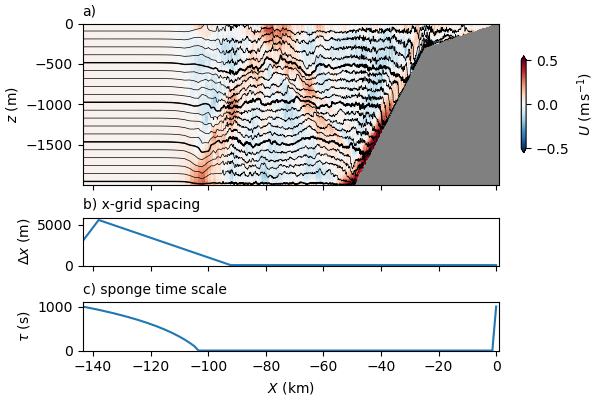

In [36]:
runname = 'Slope2D108'  # near critical slope.

with xm.open_mdsdataset(f'../results/{runname}/input/', prefix=['spinup'], geometry='cartesian', endian='<',) as ds:
    display(ds)
    ds = preprocess_run(ds)
    ds['UVEL'] = ds.UVEL.where(ds.maskW > 0)
    ds['THETA'] = ds.THETA.where(ds.maskC > 0)

    fig, axs = plt.subplots(3, 1, figsize=(6, 4), layout='constrained', height_ratios=[1, 0.3, 0.3], sharex=True)
    ax = axs[0]
    pc = ax.pcolormesh(ds.XG, ds.Z, ds.UVEL.isel(time=-1), cmap=cmapU, vmin=-0.5, vmax=0.5, rasterized=True, alpha=1)
    fig.colorbar(pc, ax=ax, label='$U\ \\mathrm{(m\\,s^{-1})}$', extend='both', shrink=0.6)
    contour_theta(ds, timeidx=-1, ax=ax, thetalevelspecial=None)
    ax.set_facecolor('grey')
    ax.set_ylim([-1999, 0])
    ax.set_ylabel('$z\ \\mathrm{(m)}$')
    ax.set_title(f'a)', fontsize='medium', loc='left')

    ax = axs[1]
    ax.plot(ds.XC, ds.dxC)
    ax.set_ylim([0, 5900])
    ax.set_ylabel('$\\Delta x\ \\mathrm{(m)}$')
    ax.set_title(f'b) x-grid spacing', fontsize='medium', loc='left')

    # sponge time scale:
    ax = axs[2]
    spongeTau = 0 * ds.XC
    spongeTau[0:13] = np.linspace(1000, 100, 13)
    spongeTau[-13:] = np.linspace(100, 1000, 13)
    ax.plot(ds.XC, spongeTau)
    ax.set_ylim([0, 1100])
    ax.set_xlim([ds.XC[0], ds.XC[-1]+1])
    ax.set_ylabel('$\\tau\ \\mathrm{(s)}$')
    ax.set_xlabel('$X\ \\mathrm{(km)}$')
    ax.set_title(f'c) sponge time scale', fontsize='medium', loc='left')
jmkfigure.jmksavenb(f'ExampleDomain{runname}', dpi=300, kinds=['png', 'pdf'])


## Figures 17, 18, 19, 20, 21

Created with: `python generate_figures.py --runname Slope2D103 --mooringZ -1750 -1250 -750 --xlim -80 0 --run-comment 'Multiple slopes, u0=0.45 m/s' --force-histogram --thetalevelspecial 0`
